# Phase 14: Time-Series Cross-Validation

This notebook evaluates the XGBoost OTP forecasting model using time-aware cross-validation.

Instead of relying on a single train-test split, this phase uses multiple chronological train-test splits to evaluate whether the model performs consistently across different historical periods.

This approach avoids random shuffling and respects the time-series structure of the data.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# Create output folders
os.makedirs("../outputs/reports", exist_ok=True)
os.makedirs("../outputs/predictions", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

In [2]:
#Loading Feature Dataset
features_path = "../outputs/predictions/staten_island_otp_features.csv"

features_df = pd.read_csv(features_path)

features_df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,...,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,Delayed_Trains_Lag_1,Scheduled_Trips_Lag_1,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP
0,2006-07-01,7-Day,104,3362,0.970,192,3274,0.945,3466,26.0,...,0.983,0.968,0.965,61.0,3490.0,0.972000,0.974833,97.666667,0.030006,0.971
1,2006-08-01,7-Day,105,3506,0.971,160,3451,0.956,3611,0.0,...,0.970,0.983,0.968,104.0,3466.0,0.973667,0.978333,92.666667,0.029078,0.953
2,2006-09-01,7-Day,159,3228,0.953,220,3167,0.935,3387,0.0,...,0.971,0.970,0.983,105.0,3611.0,0.974667,0.976167,90.000000,0.046944,0.955
3,2006-10-01,7-Day,159,3401,0.955,220,3340,0.938,3560,38.0,...,0.953,0.971,0.970,159.0,3387.0,0.964667,0.968333,122.666667,0.044663,0.930
4,2006-11-01,7-Day,239,3197,0.930,303,3133,0.912,3436,20.0,...,0.955,0.953,0.971,159.0,3560.0,0.959667,0.966667,141.000000,0.069558,0.980


In [3]:
features_df.columns

Index(['Month', 'Day Time', 'Delayed Trains', 'On-Time Trips',
       'On-Time Performance', 'Delayed Trains (With Boat)',
       'On-Time Trips (With Boat)', 'On-Time Performance (With Boat)',
       'Scheduled Trips', 'Incomplete Trips', 'Trip Complete Percentage',
       'Year', 'Month_Number', 'Month_Name', 'Quarter', 'Season', 'OTP_Lag_1',
       'OTP_Lag_2', 'OTP_Lag_3', 'Delayed_Trains_Lag_1',
       'Scheduled_Trips_Lag_1', 'OTP_Rolling_3', 'OTP_Rolling_6',
       'Delayed_Trains_Rolling_3', 'Delay_Rate', 'Next_Month_OTP'],
      dtype='object')

In [4]:
# Make a copy
df = features_df.copy()

# Convert Month to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Keep only 7-Day records
df = df[df["Day Time"] == "7-Day"].copy()

# Create target month because the model predicts next month's OTP
df["target_month"] = df["Month"] + pd.DateOffset(months=1)

# Convert target to numeric
df["Next_Month_OTP"] = pd.to_numeric(df["Next_Month_OTP"], errors="coerce")

# Convert target to percentage scale if needed
if df["Next_Month_OTP"].max() <= 1.5:
    df["target_otp"] = df["Next_Month_OTP"] * 100
else:
    df["target_otp"] = df["Next_Month_OTP"]

# Drop rows with missing target
df = df.dropna(subset=["target_otp"])

# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=["Day Time", "Season"],
    drop_first=True
)

df_encoded = df_encoded.sort_values("target_month").reset_index(drop=True)

print("Dataset shape:", df_encoded.shape)
print("Start target month:", df_encoded["target_month"].min())
print("End target month:", df_encoded["target_month"].max())

df_encoded.head()

Dataset shape: (234, 29)
Start target month: 2006-08-01 00:00:00
End target month: 2026-01-01 00:00:00


,Month,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,Trip Complete Percentage,...,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP,target_month,target_otp,Season_Spring,Season_Summer,Season_Winter
0,2006-07-01,104,3362,0.970,192,3274,0.945,3466,26.0,99.2,...,0.972000,0.974833,97.666667,0.030006,0.971,2006-08-01,97.1,False,True,False
1,2006-08-01,105,3506,0.971,160,3451,0.956,3611,0.0,100.0,...,0.973667,0.978333,92.666667,0.029078,0.953,2006-09-01,95.3,False,True,False
2,2006-09-01,159,3228,0.953,220,3167,0.935,3387,0.0,100.0,...,0.974667,0.976167,90.000000,0.046944,0.955,2006-10-01,95.5,False,False,False
3,2006-10-01,159,3401,0.955,220,3340,0.938,3560,38.0,98.9,...,0.964667,0.968333,122.666667,0.044663,0.930,2006-11-01,93.0,False,False,False
4,2006-11-01,239,3197,0.930,303,3133,0.912,3436,20.0,99.4,...,0.959667,0.966667,141.000000,0.069558,0.980,2006-12-01,98.0,False,False,False


### Define Feature Columns and Target

In [6]:
exclude_cols = [
    "Month",
    "On-Time Performance",
    "On-Time Performance (With Boat)",
    "Next_Month_OTP",
    "target_month",
    "target_otp",
    "Month_Name"   # Drop text column because XGBoost needs numeric features
]

feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded["target_otp"]
dates = df_encoded["target_month"]

print("Number of features:", len(feature_cols))
print(feature_cols)

# Confirm all selected features are numeric
print("\nFeature data types:")
print(X.dtypes)

Number of features: 22
['Delayed Trains', 'On-Time Trips', 'Delayed Trains (With Boat)', 'On-Time Trips (With Boat)', 'Scheduled Trips', 'Incomplete Trips', 'Trip Complete Percentage', 'Year', 'Month_Number', 'Quarter', 'OTP_Lag_1', 'OTP_Lag_2', 'OTP_Lag_3', 'Delayed_Trains_Lag_1', 'Scheduled_Trips_Lag_1', 'OTP_Rolling_3', 'OTP_Rolling_6', 'Delayed_Trains_Rolling_3', 'Delay_Rate', 'Season_Spring', 'Season_Summer', 'Season_Winter']

Feature data types:
Delayed Trains                  int64
On-Time Trips                   int64
Delayed Trains (With Boat)      int64
On-Time Trips (With Boat)       int64
Scheduled Trips                 int64
Incomplete Trips              float64
Trip Complete Percentage      float64
Year                            int64
Month_Number                    int64
Quarter                         int64
OTP_Lag_1                     float64
OTP_Lag_2                     float64
OTP_Lag_3                     float64
Delayed_Trains_Lag_1          float64
Scheduled_Tr

In [7]:
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: ['Season_Spring', 'Season_Summer', 'Season_Winter']


### Define Evaluation Function

In [8]:
def evaluate_fold(y_true, y_pred):
    """
    Evaluate one cross-validation fold.
    Metrics are measured in OTP percentage points.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
    ) * 100

    return mae, rmse, r2, mape

In [9]:
n_splits = 5

tscv = TimeSeriesSplit(n_splits=n_splits)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


### Time-Series Cross-Validation

In [10]:
cv_results = []
cv_predictions = []

fold_number = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    date_train, date_test = dates.iloc[train_index], dates.iloc[test_index]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae, rmse, r2, mape = evaluate_fold(y_test, y_pred)

    cv_results.append({
        "Fold": fold_number,
        "Train_Start": date_train.min(),
        "Train_End": date_train.max(),
        "Test_Start": date_test.min(),
        "Test_End": date_test.max(),
        "Train_Rows": len(train_index),
        "Test_Rows": len(test_index),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    })

    fold_predictions = pd.DataFrame({
        "Fold": fold_number,
        "month": date_test.values,
        "actual_otp": y_test.values,
        "predicted_otp": y_pred
    })

    cv_predictions.append(fold_predictions)

    fold_number += 1

cv_results_df = pd.DataFrame(cv_results)
cv_predictions_df = pd.concat(cv_predictions, ignore_index=True)

cv_results_df

,Fold,Train_Start,Train_End,Test_Start,Test_End,Train_Rows,Test_Rows,MAE,RMSE,R2,MAPE
0,1,2006-08-01,2009-10-01,2009-11-01,2013-01-01,39,39,2.929581,4.579477,-0.129012,3.296488
1,2,2006-08-01,2013-01-01,2013-02-01,2016-04-01,78,39,2.338942,2.925027,0.247627,2.513076
2,3,2006-08-01,2016-04-01,2016-05-01,2019-07-01,117,39,2.024579,2.410638,0.514363,2.106241
3,4,2006-08-01,2019-07-01,2019-08-01,2022-10-01,156,39,1.960149,2.340654,-0.309165,2.027315
4,5,2006-08-01,2022-10-01,2022-11-01,2026-01-01,195,39,1.300282,2.017963,0.586052,1.395257


In [11]:
cv_results_rounded = cv_results_df.copy()

numeric_cols = ["MAE", "RMSE", "R2", "MAPE"]
cv_results_rounded[numeric_cols] = cv_results_rounded[numeric_cols].round(4)

cv_results_rounded

,Fold,Train_Start,Train_End,Test_Start,Test_End,Train_Rows,Test_Rows,MAE,RMSE,R2,MAPE
0,1,2006-08-01,2009-10-01,2009-11-01,2013-01-01,39,39,2.9296,4.5795,-0.1290,3.2965
1,2,2006-08-01,2013-01-01,2013-02-01,2016-04-01,78,39,2.3389,2.9250,0.2476,2.5131
2,3,2006-08-01,2016-04-01,2016-05-01,2019-07-01,117,39,2.0246,2.4106,0.5144,2.1062
3,4,2006-08-01,2019-07-01,2019-08-01,2022-10-01,156,39,1.9601,2.3407,-0.3092,2.0273
4,5,2006-08-01,2022-10-01,2022-11-01,2026-01-01,195,39,1.3003,2.0180,0.5861,1.3953


In [12]:
cv_results_rounded.to_csv(
    "../outputs/reports/phase14_timeseries_cv_results.csv",
    index=False
)

cv_predictions_df.to_csv(
    "../outputs/predictions/phase14_cv_predictions.csv",
    index=False
)

### Create CV Summary Table

In [13]:
cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "MAPE"],
    "Mean": [
        cv_results_df["MAE"].mean(),
        cv_results_df["RMSE"].mean(),
        cv_results_df["R2"].mean(),
        cv_results_df["MAPE"].mean()
    ],
    "Standard_Deviation": [
        cv_results_df["MAE"].std(),
        cv_results_df["RMSE"].std(),
        cv_results_df["R2"].std(),
        cv_results_df["MAPE"].std()
    ],
    "Minimum": [
        cv_results_df["MAE"].min(),
        cv_results_df["RMSE"].min(),
        cv_results_df["R2"].min(),
        cv_results_df["MAPE"].min()
    ],
    "Maximum": [
        cv_results_df["MAE"].max(),
        cv_results_df["RMSE"].max(),
        cv_results_df["R2"].max(),
        cv_results_df["MAPE"].max()
    ]
})

cv_summary[["Mean", "Standard_Deviation", "Minimum", "Maximum"]] = (
    cv_summary[["Mean", "Standard_Deviation", "Minimum", "Maximum"]].round(4)
)

cv_summary

,Metric,Mean,Standard_Deviation,Minimum,Maximum
0,MAE,2.1107,0.5936,1.3003,2.9296
1,RMSE,2.8548,1.0175,2.0180,4.5795
2,R2,0.1820,0.3924,-0.3092,0.5861
3,MAPE,2.2677,0.7006,1.3953,3.2965


In [14]:
cv_summary.to_csv(
    "../outputs/reports/phase14_timeseries_cv_summary.csv",
    index=False
)

### MAE by Fold Chart

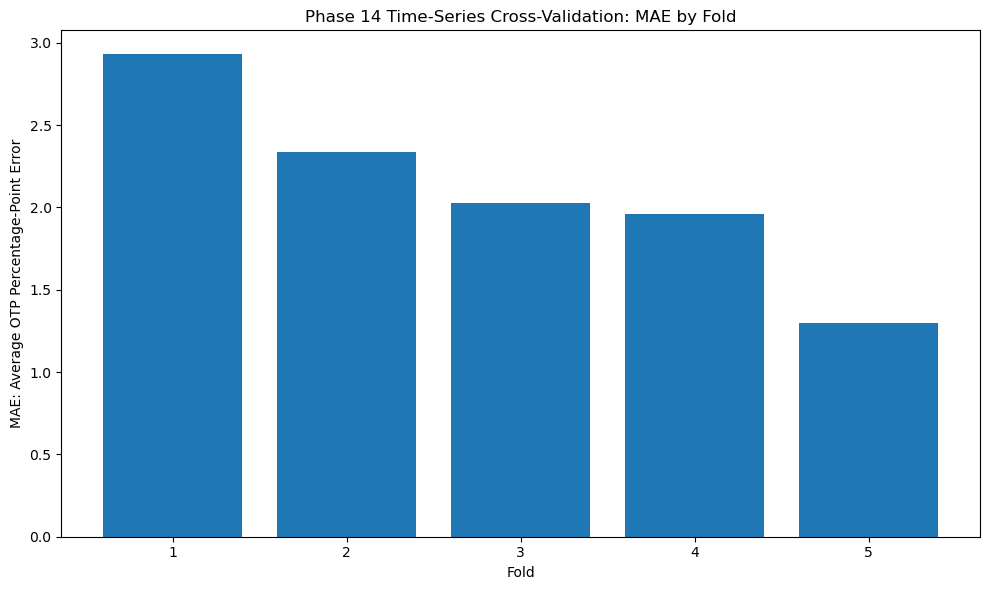

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    cv_results_rounded["Fold"].astype(str),
    cv_results_rounded["MAE"]
)

plt.title("Phase 14 Time-Series Cross-Validation: MAE by Fold")
plt.xlabel("Fold")
plt.ylabel("MAE: Average OTP Percentage-Point Error")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase14_cv_mae_by_fold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Actual vs Predicted Across CV Folds

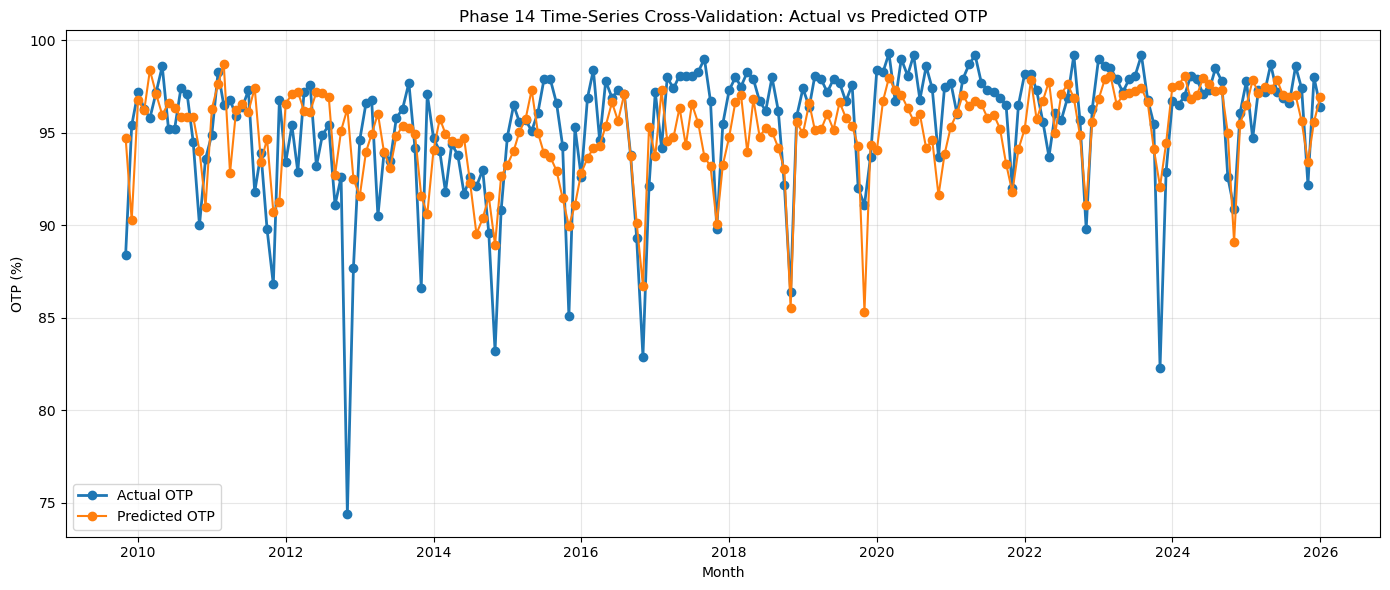

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    cv_predictions_df["month"],
    cv_predictions_df["actual_otp"],
    marker="o",
    linewidth=2,
    label="Actual OTP"
)

plt.plot(
    cv_predictions_df["month"],
    cv_predictions_df["predicted_otp"],
    marker="o",
    label="Predicted OTP"
)

plt.title("Phase 14 Time-Series Cross-Validation: Actual vs Predicted OTP")
plt.xlabel("Month")
plt.ylabel("OTP (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/phase14_cv_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Fold Period Table

In [17]:
cv_results_rounded[[
    "Fold",
    "Train_Start",
    "Train_End",
    "Test_Start",
    "Test_End",
    "Train_Rows",
    "Test_Rows"
]]

,Fold,Train_Start,Train_End,Test_Start,Test_End,Train_Rows,Test_Rows
0,1,2006-08-01,2009-10-01,2009-11-01,2013-01-01,39,39
1,2,2006-08-01,2013-01-01,2013-02-01,2016-04-01,78,39
2,3,2006-08-01,2016-04-01,2016-05-01,2019-07-01,117,39
3,4,2006-08-01,2019-07-01,2019-08-01,2022-10-01,156,39
4,5,2006-08-01,2022-10-01,2022-11-01,2026-01-01,195,39


### Auto-Generate Findings Text

In [18]:
avg_mae = cv_results_df["MAE"].mean()
avg_rmse = cv_results_df["RMSE"].mean()
avg_r2 = cv_results_df["R2"].mean()
avg_mape = cv_results_df["MAPE"].mean()

std_mae = cv_results_df["MAE"].std()
best_fold = cv_results_df.loc[cv_results_df["MAE"].idxmin(), "Fold"]
worst_fold = cv_results_df.loc[cv_results_df["MAE"].idxmax(), "Fold"]

findings_text = f"""
Phase 14 evaluated the XGBoost OTP forecasting model using time-series cross-validation with {n_splits} chronological folds.

Across the cross-validation folds, the model achieved an average MAE of {avg_mae:.4f} OTP percentage points and an average RMSE of {avg_rmse:.4f}. The average R² was {avg_r2:.4f}, and the average MAPE was {avg_mape:.4f}%.

The standard deviation of MAE across folds was {std_mae:.4f}, which indicates the level of variation in model performance across different historical test periods.

The best-performing fold was Fold {best_fold}, while the weakest-performing fold was Fold {worst_fold} based on MAE.

This validation approach provides a more rigorous evaluation than a single train-test split because it tests the model across multiple future periods while preserving chronological order.
"""

print(findings_text)


Phase 14 evaluated the XGBoost OTP forecasting model using time-series cross-validation with 5 chronological folds.

Across the cross-validation folds, the model achieved an average MAE of 2.1107 OTP percentage points and an average RMSE of 2.8548. The average R² was 0.1820, and the average MAPE was 2.2677%.

The standard deviation of MAE across folds was 0.5936, which indicates the level of variation in model performance across different historical test periods.

The best-performing fold was Fold 5, while the weakest-performing fold was Fold 1 based on MAE.

This validation approach provides a more rigorous evaluation than a single train-test split because it tests the model across multiple future periods while preserving chronological order.



In [19]:
with open("../outputs/reports/phase14_findings.txt", "w") as f:
    f.write(findings_text)

# Phase 14 Findings

Phase 14 evaluated the XGBoost OTP forecasting model using time-series cross-validation. Unlike a single train-test split, this method evaluates the model across multiple chronological folds, where each fold trains on past data and tests on a later future period.

Across the five cross-validation folds, the model achieved an average MAE of **2.1107 OTP percentage points** and an average RMSE of **2.8548**. The average R² was **0.1820**, and the average MAPE was **2.2677%**.

The fold-level results show that model performance improved as more historical training data became available. Fold 1, which trained on the smallest amount of historical data, had the weakest performance with an MAE of **2.9296** and an R² of **-0.1290**. Fold 5, which trained on the largest and most recent historical window, achieved the best performance with an MAE of **1.3003** and an R² of **0.5861**.

This pattern suggests that the XGBoost model benefits from a longer historical training window and may become more reliable as additional monthly OTP data is added. However, performance still varies across time periods, indicating that OTP is influenced by operational factors not fully captured in the current feature set.

Overall, Phase 14 strengthens the project by showing that the model was evaluated using a time-aware validation strategy rather than relying only on one train-test split. The results show that XGBoost has predictive value across multiple historical periods, while also highlighting the need for additional features such as weather, incident-level delays, track work, ferry connection effects, or seasonal operating conditions to improve robustness.